# Hidden-Node Abstention — turning a bare `off-model` into an honest differential

**Thesis (one line):** when NUDGE's switch model is *inadequate*, it does **not** guess a
cause — it emits a legible **differential diagnosis** of *why*, and it **never** claims it
found a hidden node.

NUDGE's crown-jewel fail-safe returns **`off-model`** rather than manufacture a switch. But
`off-model` alone doesn't tell you what to do next — and the one thing you're most tempted
to conclude (a leftover residual *is* a newly-discovered hidden regulator) is exactly what
the data **cannot** support. `NUDGE-METHOD-009` (`nudge.inference.hidden_node`) packages the
evidence into a **six-cause differential**, each with its documented limitation and the
experiment that would distinguish it.

**The honesty crux — `NUDGE-LIM-015` (abstention half ONLY).** Positive hidden-node
identification is *not identifiable* from an off-model verdict: the six causes are
**observationally overlapping** (they all present as "the affine switch model doesn't fit"),
and there's essentially no real Perturb-seq data with a *known* hidden node to calibrate a
detector against. So NUDGE ships **only the abstention**. The strongest it ever says about a
hidden node is that an off-axis residual is *consistent with — but does not prove —* an
unmeasured regulator. **The differential is a hypothesis-ranking aid, not a discovery.**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import matplotlib.pyplot as plt
import numpy as np

from nudge.inference.hidden_node import diagnose_inadequacy
from nudge.service import diagnose_abstention

RANK_COLOR = {"leading": "#c0392b", "plausible": "#e67e22", "less-likely": "#7f8c8d"}
print("hidden-node abstention loaded — the abstention HALF only (NUDGE-METHOD-009)")

hidden-node abstention loaded — the abstention HALF only (NUDGE-METHOD-009)


## 1. An off-model case → the enumerated differential

We feed the method the *evidence* a real attribution would already have produced: the
**`off_model`** parsimony verdict, plus a large **off-axis / neomorphic residual**
(`neomorphic_ratio = 2.5`, from `epistasis.ComboGeometry`) — the very signal a naive tool
would over-read as "hidden node found." NUDGE instead lays out all six candidate causes,
ranked, each with the experiment that would distinguish it.

In [2]:
report = diagnose_inadequacy(off_model=True, neomorphic_ratio=2.5)

print(f"is_adequate = {report.is_adequate}   verdict = {report.verdict!r}\n")
for i, c in enumerate(report.ranked_causes(), 1):
    refs = "  ".join(x for x in (c.limitation_ref, c.decoy_ref) if x) or "—"
    print(f"{i}. [{c.qualitative_rank:11}] {c.name}   ({refs})")

# Ground-truth assert: the full six-cause differential is enumerated.
names = {c.name for c in report.causes}
assert len(names) == 6, names
assert report.is_adequate is False
print("\n✓ six candidate causes enumerated — a differential, not a verdict")

is_adequate = False   verdict = 'off-model'

1. [leading    ] genuinely not-a-switch (linear circuit)   (NUDGE-LIM-005  NUDGE-DECOY-005)
2. [plausible  ] nonlinear measurement readout   (NUDGE-LIM-006)
3. [plausible  ] off-target perturbation effect   (NUDGE-LIM-004  NUDGE-DECOY-004)
4. [plausible  ] hidden node / unmeasured regulator   (NUDGE-LIM-015)
5. [less-likely] wrong / misspecified topology   (—)
6. [less-likely] batch / depth confound   (NUDGE-LIM-003  NUDGE-DECOY-003)

✓ six candidate causes enumerated — a differential, not a verdict


### The differential, visualized

Each bar is one candidate cause, colored by its **qualitative rank** (`leading` /
`plausible` / `less-likely`). Note the shape of the honesty: on an `off-model` verdict the
**parsimony gate's own reading — "genuinely not a switch" — leads** (the gate working as
designed), and the **hidden-node hypothesis is capped below it**, never the lone leading
answer, no matter how large the residual.

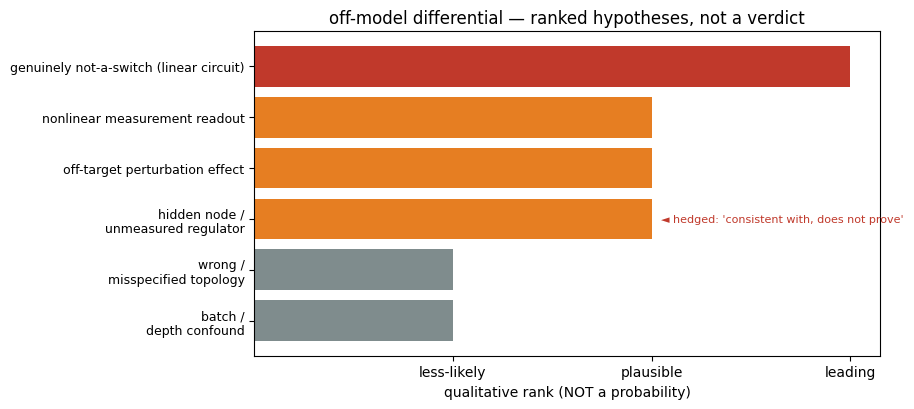

In [3]:
causes = report.ranked_causes()
rank_val = {"leading": 3, "plausible": 2, "less-likely": 1}
vals = [rank_val[c.qualitative_rank] for c in causes]
labels = [c.name.replace(" / ", " /\n") for c in causes]
colors = [RANK_COLOR[c.qualitative_rank] for c in causes]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(range(len(causes)), vals, color=colors)
ax.set_yticks(range(len(causes)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["less-likely", "plausible", "leading"])
ax.set_xlabel("qualitative rank (NOT a probability)")
ax.set_title("off-model differential — ranked hypotheses, not a verdict")
for i, c in enumerate(causes):
    if c.name.startswith("hidden node"):
        ax.text(vals[i] + 0.05, i, "◄ hedged: 'consistent with, does not prove'",
                va="center", fontsize=8, color="#c0392b")
plt.tight_layout()
plt.show()

## 2. The hidden-node cause — read the actual words

The whole capability lives or dies on *how* the hidden-node hypothesis is worded. Here is
the exact evidence string and the distinguishing experiment NUDGE emits.

In [4]:
hidden = next(c for c in report.causes if c.name.startswith("hidden node"))
print("CAUSE:", hidden.name, f"[{hidden.qualitative_rank}]  ->  {hidden.limitation_ref}\n")
print("evidence:\n ", hidden.evidence, "\n")
print("distinguishing experiment:\n ", hidden.distinguishing_experiment)

CAUSE: hidden node / unmeasured regulator [plausible]  ->  NUDGE-LIM-015

evidence:
  an off-axis / neomorphic residual (ratio 2.50 ≥ 1) is CONSISTENT WITH — but does NOT prove — an unmeasured regulator / emergent state the measured axes do not span. It is observationally indistinguishable from the other causes below; NUDGE does NOT assert a hidden node (NUDGE-LIM-015, NUDGE-LIM-009) 

distinguishing experiment:
  measure the candidate regulator directly (add it to the panel / a multiome or multi-reporter readout) so the off-axis dimension becomes an ON-axis measured one — only a positive measurement, not a residual, can establish a hidden node


## 3. The honesty guarantee — NEVER a positive hidden-node claim

This is the load-bearing test (mirrored in `tests/inference/test_hidden_node.py`). Even in
the **most tempting** regime — a huge off-axis residual (`ratio = 12`) — we scan *every*
string the report emits for a bare positive assertion, and confirm the hidden-node cause is
explicitly hedged. If NUDGE ever asserted a hidden node, this cell would fail.

In [5]:
tempting = diagnose_inadequacy(off_model=True, neomorphic_ratio=12.0)
text = "\n".join(
    [tempting.reason] + [s for c in tempting.causes
                         for s in (c.name, c.evidence, c.distinguishing_experiment)]
).lower()

forbidden = [
    r"hidden node detected", r"there is a hidden node", r"a hidden node is present",
    r"hidden node found", r"proves? (?:the existence of )?a hidden node",
    r"confirm\w* a hidden node",
]
for pat in forbidden:
    assert not re.search(pat, text), f"FORBIDDEN positive claim: {pat!r}"

hidden = next(c for c in tempting.causes if c.name.startswith("hidden node"))
ev = hidden.evidence.lower()
assert "consistent with" in ev and ("does not prove" in ev or "not prove" in ev)
print("✓ no bare positive hidden-node claim anywhere in the report")
print("✓ hidden-node evidence is hedged: 'consistent with ... does NOT prove'")
print("✓ ranks:", {c.qualitative_rank for c in tempting.causes})
print("\nThis is the abstention-half-only guarantee (NUDGE-LIM-015), enforced in CI.")

✓ no bare positive hidden-node claim anywhere in the report
✓ hidden-node evidence is hedged: 'consistent with ... does NOT prove'
✓ ranks: {'leading', 'less-likely', 'plausible'}

This is the abstention-half-only guarantee (NUDGE-LIM-015), enforced in CI.


## 4. The adequate case → no differential

When there's **no** off-model verdict and **no** diagnostic residual, the switch model is
adequate — so there is nothing to explain, and NUDGE **invents no differential**. Honesty
runs both ways: it doesn't manufacture causes any more than it manufactures a hidden node.

In [6]:
ok = diagnose_inadequacy(off_model=False)
print(f"is_adequate = {ok.is_adequate}   verdict = {ok.verdict!r}   causes = {ok.causes}")
assert ok.is_adequate is True and ok.causes == []
print("\nreason:", ok.reason)

# A below-threshold residual with no off-model verdict also stays adequate.
ok2 = diagnose_inadequacy(off_model=False, neomorphic_ratio=0.2)
assert ok2.is_adequate is True and ok2.causes == []
print("\n✓ small residual, no off-model → still adequate, no differential")

is_adequate = True   verdict = 'model-adequate'   causes = []

reason: no off-model verdict and no diagnostic residual fired — the switch model is adequate for this attribution; there is no inadequacy to explain, so no differential is emitted (and, per NUDGE-LIM-015, none is invented)

✓ small residual, no off-model → still adequate, no differential


## 5. The service / CLI / MCP path

The same differential is one call away for a human (`nudge diagnose-abstention`) or Claude
(the `diagnose_abstention` MCP tool). The serialized payload carries a machine-readable
`hidden_node_claim: False` and enriches each cause with its limitation *title* via the
read-only `knowledge.explain` backbone.

In [7]:
out = diagnose_abstention(off_model=True, neomorphic_ratio=2.0, readout_flag=True)
print("verdict:", out["verdict"], "| hidden_node_claim:", out["hidden_node_claim"])
print("honesty_note:", out["honesty_note"], "\n")
for c in out["causes"]:
    title = f" — {c['limitation_title']}" if c["limitation_title"] else ""
    print(f"  [{c['qualitative_rank']:11}] {c['name']}  ({c['limitation_ref'] or '—'}{title})")

assert out["hidden_node_claim"] is False
# The readout flag promoted the nonlinear-readout cause to leading.
ro = next(c for c in out["causes"] if c["name"] == "nonlinear measurement readout")
assert ro["qualitative_rank"] == "leading"
print("\n✓ readout flag promoted the nonlinear-readout hypothesis to leading")

verdict: off-model | hidden_node_claim: False
honesty_note: This is a DIFFERENTIAL of candidate causes, not a verdict. NUDGE never positively asserts a hidden node from an off-model result — the causes are observationally overlapping (NUDGE-LIM-015). 

  [leading    ] genuinely not-a-switch (linear circuit)  (NUDGE-LIM-005 — A marginal nonlinearity must not be over-called as a switch)
  [leading    ] nonlinear measurement readout  (NUDGE-LIM-006 — A nonlinear measurement readout is misattributed as a circuit switch)
  [plausible  ] off-target perturbation effect  (NUDGE-LIM-004 — A targeted-but-ineffective perturbation must not be reported as a mechanism)
  [plausible  ] hidden node / unmeasured regulator  (NUDGE-LIM-015 — A hidden node cannot be positively identified from an off-model verdict — NUDGE ships only the abstention)
  [less-likely] wrong / misspecified topology  (—)
  [less-likely] batch / depth confound  (NUDGE-LIM-003 — Technical dropout can produce a switch-like zero-pea

## What this buys — and where it goes next

- **What it buys.** A bare `off-model` becomes *"here is why the model is inadequate, and
  what to measure next"* — a **six-cause differential** (not-a-switch, nonlinear readout,
  off-target, wrong topology, batch/depth confound, hidden node), each mapped to a
  documented `NUDGE-LIM-*` and a concrete distinguishing experiment.
- **The honest boundary (`NUDGE-LIM-015`).** NUDGE ships **only** the abstention half. It
  **never** asserts a hidden node — the causes are observationally overlapping, so the
  strongest statement is *consistent with, does not prove*. Positive identification would
  need a positive **measurement** (add the candidate regulator to the panel), not a residual.
- **Reproduce it.** `nudge diagnose-abstention --off-model --neomorphic-ratio 2.5` (CLI), the
  `diagnose_abstention` MCP tool, or `nudge.inference.hidden_node.diagnose_inadequacy(...)`.
  Resolve any `NUDGE-LIM-*` / `NUDGE-DECOY-*` with `nudge explain <id>`.